# 3.3 Clustering: Unsupervised Classification

Clustering is a form of *unsupervised classification*: the algorithm discovers structure in the data from the features alone, without labels. The goal is to group observations into coherent subgroups.

Whether a group is coherent depends on the *distance* between data points. The distance metric quantifies how similar or dissimilar two data points are, and every clustering algorithm relies on one.

This tutorial does not cover all possible clustering methods. No single clustering method works best for all scenarios; the right choice depends strongly on the inherent data structure. A simple summary, with toy examples of 2D data structure, is available in the [sklearn package](https://scikit-learn.org/stable/modules/clustering.html#overview-of-clustering-methods).

This lecture focuses on fundamental concepts that are relevant to the geosciences: 1) the definition of ***distance***, illustrated with the most popular clustering algorithm, 2) K-means clustering, and 3) agglomerative clustering.

## 1. Distance
Distance is the basic measure of dissimilarity between data points, and clustering results depend directly on the metric you choose. Distance also returns later in the course as the building block of loss and cost functions for training deep learning models.

There are various ways to estimate and quantify distance between data points. Some of the most commonly used distance metrics include:

* **Euclidean Distance**: This is the straight-line distance between two data points in a multidimensional space. It is often used when the data features have similar units or scales.
        $d(\mathbf{x},\mathbf{y}) = \sqrt{ \sum_{i=1}^N (x_i-y_i)^2  }/N$

* **Manhattan Distance**: Also known as the 'L1' distance, it measures the sum of the absolute differences between corresponding elements of two data points. It's suitable when movement along axes is restricted, such as in grid-based data.
        $d(\mathbf{x},\mathbf{y}) =  \sum_{i=1}^N |x_i-y_i| /N$

* **Geodesic Distance**: Geodesic distance measures the shortest path between two points on the surface of a sphere. It matters for Earth's geography, including GPS navigation and geodetic measurements.

* **Correlation-Based Distances**: In geophysical and geospatial data analysis, correlation-based distance metrics like *Pearson correlation* or *Spearman rank correlation* are often used to assess relationships between variables.

* **Covariance-Based Distances**: These distances, which take into account the spatial covariance or variogram models, are prevalent in geostatistics and spatial analysis.

* **Cosine Similarity**: This metric calculates the cosine of the angle between two data vectors, providing a measure of their similarity, particularly in high-dimensional spaces. It's frequently used for text or image data.

Scikit-learn contains the most commonly used metrics in the context of Classic ML under the package ``metrics.DistanceMetric``. More details in this scikit-learn [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.DistanceMetric.html).

***Relation to PCA***
Clustering and PCA both simplify the data via a small number of summaries. But the differences are:
* PCA seeks to reduce the dimensionality of the data, to find a low-dimensional representation of the data that explains a good fraction of the data variance,
* Clustering seeks to find homogeneous groups within the observations.

In fact, it is common to combine both for complex and high dimensional data: 1) PCA, 2) clustering on the PCs.

There are two main methods using clustering, **k-means** clustering and **hierarchical clustering**.

The toolbox scikit-learn has a collection of clustering algorithms and detailed [documentation](https://scikit-learn.org/stable/modules/clustering.html) with tutorials.

## 2. Tutorial set up
Import useful Python packages.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pooch
from sklearn import preprocessing
from sklearn.decomposition import PCA

### Data

Earlier editions of this chapter used a 146 MB SeaFlow flow-cytometry table; we retired it in 2026 in favor of lighter datasets.

Our first working dataset is the Old Faithful geyser record from Yellowstone. Each row pairs the duration of one eruption (`current`, in minutes) with the duration of the following eruption (`next`, in minutes). We download it with `pooch`, which caches the file locally.

In [2]:
path = pooch.retrieve(
    url="https://raw.githubusercontent.com/UW-MLGEO/MLGeo-dataset/main/data/faithful.csv",
    known_hash=None,
    fname="faithful.csv",
    path=pooch.os_cache("mlgeo"),
)
faithful = pd.read_csv(path)
faithful.head()

,current,next
0,3.600,1.800
1,1.800,3.333
2,3.333,2.283
3,2.283,4.533
4,4.533,2.883


Text(0.5, 1.0, 'Old Faithful')

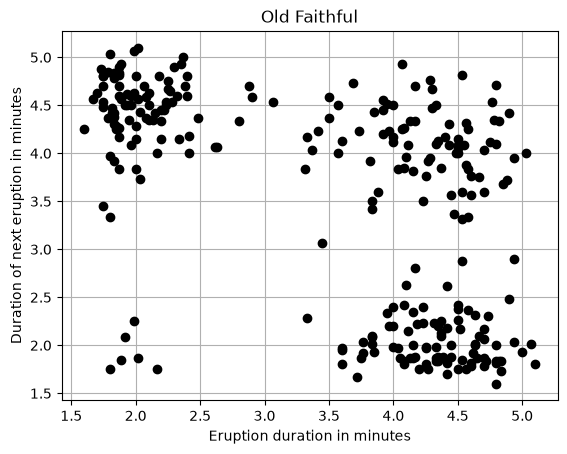

In [3]:
plt.plot(faithful.current, faithful.next, 'ko')
plt.xlabel('Eruption duration in minutes')
plt.ylabel('Duration of next eruption in minutes')
plt.grid(True)
plt.title('Old Faithful')

K-means relies on Euclidean distance, so features with larger numeric ranges dominate the result. Here both columns happen to be in minutes with similar ranges, but that is a coincidence of this dataset. Standardizing each feature (zero mean, unit variance) is a habit to keep for any distance-based method — in the seismic exercise at the end of this notebook, the features span orders of magnitude and scaling is not optional. We standardize now and store the result in `data_faithful`, a 2-column numpy array.

In [4]:
scaler = preprocessing.StandardScaler()
data_faithful = scaler.fit_transform(faithful[["current", "next"]])
print(data_faithful.shape)

(271, 2)


## 3. K-means
K-means is an unsupervised clustering method. The main idea is to separate the data into K distinct clusters. We then have two problems to solve. First, we need to find the k centroids of the k clusters. Then, we need to affect each data point to the cluster which centroid is the closest to the data point.

The goal is to partition $n$ data points into $k$ clusters. Each observation is labeled to a cluster with the nearest mean.

K-means is iterative:
1. assume initial values for the mean of each of the $k$ clusters
2. Compute the distance for each observation to each of the $k$ means
3. Label each observation as belonging to the nearest means
4. Find the *center of mass* (mean) of each group of labeled points. These are new means to step 1.

In the following, we denote $n$ the number of data points, and $p$ the number of features for each data point.

K-means only works with the **Euclidian distance** metrics. In fact, its core concept is to use the euclidian distance to measure and minimize *inertia* or *within cluster variation*.

In [5]:
n, p = data_faithful.shape
print('We have {:d} data points, and each one has {:d} features'.format(n, p))

We have 271 data points, and each one has 2 features


Let us define a function to initialize the centroid of the clusters. We choose random points within the range of values taken by the data.

In [6]:
def init_centers(data, k):
    """
    """
    # Initialize centroids
    centers = np.zeros((k, np.shape(data)[1]))
    # Loop on k centers
    for i in range(0, k):
        # Generate p random values between 0 and 1
        dist = np.random.uniform(size=np.shape(data)[1])
        # Use the random values to generate a point within the range of values taken by the data
        centers[i, :] = np.min(data, axis=0) + (np.max(data, axis=0) - np.min(data, axis=0)) * dist
    return centers

To be able to affect each data point to the closest centroid, we need to define the distance between two data points. The most common distance is the **Euclidean distance**:

$d(x,y) = \sqrt{\sum_{i = 1}^p (x_i - y_i)^2}$

where $x$ and $y$ are two data observation points with $p$ variables.

We then define a function to compute the distance between each data point and each centroid.

In [7]:
def compute_distance(data, centers, k):
    """
    """
    # Initialize distance
    distance = np.zeros((np.shape(data)[0], k))
    # Loop on n data points
    for i in range(0, np.shape(data)[0]):
        # Loop on k centroids
        for j in range(0, k):
            # Compute distance
            distance[i, j] = np.sqrt(np.sum(np.square(data[i, :] - centers[j, :])))
    return distance

We now define a function to affect each data point to the cluster which centroid is the closest to the point. We also define an objective function that will be minimized until we reach convergence.

Our objective is to minimize the sum of the square of the distance between each point and the closest centroid:

$obj = \sum_{j = 1}^k \sum_{i = 1}^{N_j} d(x^{(i)} , x^{(j)}) ^2$

where $x^{(i)}$ is the $i^{th}$ point in the cluster $j$, $x^{(j)}$ is the centroid of the cluster $j$, and $N_j$ is the number of points in the cluster $j$.

In [8]:
def compute_objective(distance, clusters):
    """
    """
    # Initialize objective
    objective = 0.0
    # Loop on n data points
    for i in range(0, np.shape(distance)[0]):
        # Add distance to the closest centroid
        objective = objective + distance[i, int(clusters[i])] ** 2.0
    return objective

In [9]:
def compute_clusters(distance):
    """
    """
    # Initialize clusters
    clusters = np.zeros(np.shape(distance)[0])
    # Loop on n data points
    for i in range(0, np.shape(distance)[0]):
        # Find closest centroid
        best = np.argmin(distance[i, :])
        # Assign data point to corresponding cluster
        clusters[i] = best
    return clusters

After all points are assigned to a cluster, compute the new location of the centroid. It is just the value of the mean of all the points affected to that cluster:

For $1 \leq j \leq k$, $x_p^{(j)} = \frac{1}{N_j} \sum_{i = 1}^{N_j} x_p^{(i)}$

In [10]:
def compute_centers(data, clusters, k):
    """
    """
    # Initialize centroids
    centers = np.zeros((k, np.shape(data)[1]))
    # Loop on clusters
    for i in range(0, k):
        # Select all data points in this cluster
        subdata = data[clusters == i, :]
        # If no data point in this cluster, generate randomly a new centroid
        if (np.shape(subdata)[0] == 0):
            centers[i, :] = init_centers(data, 1)
        else:
            # Compute the mean location of all data points in this cluster
            centers[i, :] = np.mean(subdata, axis=0)
    return centers

We can now code the K-means algorithm by assembling all these functions. We stop the computation when the objective function no longer decreases.

In [11]:
def my_kmeans(data, k):
    """
    """
    # Initialize centroids
    centers = init_centers(data, k)
    # Initialize objective function to square of the maximum distance between two data points times number of data points
    objective_old = np.shape(data)[0] * np.sum(np.square(np.max(data, axis=0) - np.min(data, axis=0)))
    # Initialize clusters
    clusters_old = np.zeros(np.shape(data)[0])
    # Start loop until convergence
    stop_alg = False
    while stop_alg == False:
        # Compute distance between data points and centroids
        distance = compute_distance(data, centers, k)
        # Get new clusters
        clusters_new = compute_clusters(distance)
        # get new value of objective function
        objective_new = compute_objective(distance, clusters_new)
        # If objective function stops decreasing, end loop
        if objective_new >= objective_old:
            return (clusters_old, objective_old, centers)
        else:
            # Update the locations of the centroids
            centers = compute_centers(data, clusters_new, k)
            objective_old = objective_new
            clusters_old = clusters_new

The Old Faithful data shows two regimes — short eruptions followed by short eruptions, and long eruptions followed by long eruptions — so we set `k = 2` and run our from-scratch k-means.

Text(0.5, 1.0, 'From-scratch k-means with k = 2')

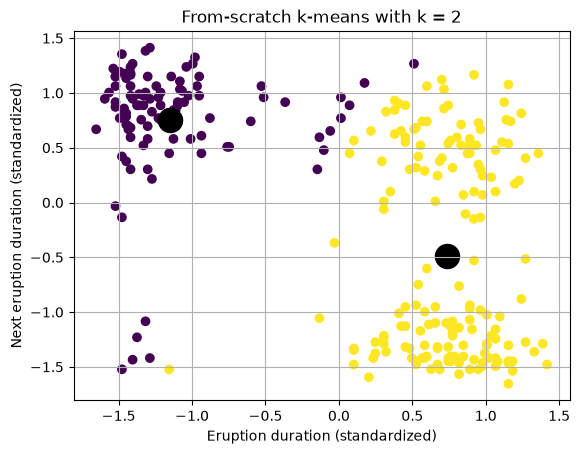

In [12]:
np.random.seed(42)
k = 2
(clusters, objective, centers) = my_kmeans(data_faithful, k)

plt.scatter(data_faithful[:, 0], data_faithful[:, 1], c=clusters)
plt.scatter(centers[:, 0], centers[:, 1], marker='o', s=300, c='black')
plt.xlabel('Eruption duration (standardized)')
plt.ylabel('Next eruption duration (standardized)')
plt.grid(True)
plt.title('From-scratch k-means with k = 2')

### K-means with Scikit learn

We now use the [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) implementation on the same scaled data.

Two defaults worth knowing: `init='k-means++'` is the default initialization scheme, and since recent scikit-learn versions `n_init` defaults to `'auto'`, which runs several k-means++ restarts and keeps the best. You no longer need to set either parameter by hand.

Text(0.5, 1.0, 'Scikit-learn KMeans with k = 2')

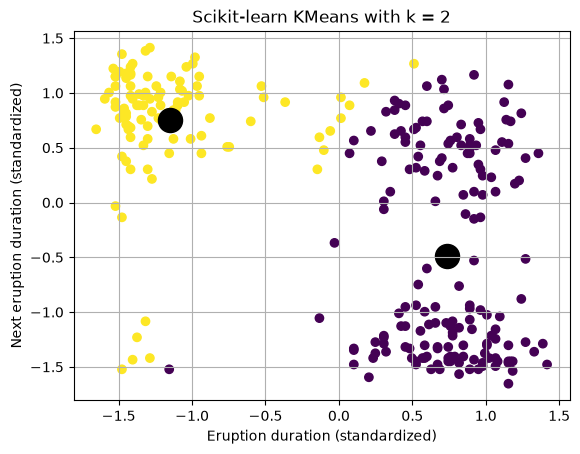

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0).fit(data_faithful)

plt.scatter(data_faithful[:, 0], data_faithful[:, 1], c=kmeans.labels_)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='o', s=300, c='black')
plt.xlabel('Eruption duration (standardized)')
plt.ylabel('Next eruption duration (standardized)')
plt.grid(True)
plt.title('Scikit-learn KMeans with k = 2')

### Practical tips for k-means

1. How to **evaluate the success** of the clustering? How well separated are the clusters? There exist many ways to evaluate the quality of the clusters. Scikit-learn has summarized and packaged these tools into the module ``sklearn.metrics``. See documentation [here](https://scikit-learn.org/stable/modules/clustering.html#clustering-evaluation). Usually, high scores are better. Here is a summary:
    * If the data has ground-truth labels (e.g., the seismic source types in the exercise below), we can use several metrics:
        + **homogeneity** (each cluster contains only members of a given class, ``metrics.homogeneity_score(clusterID,true_label)``), **completeness** (all members of a given class are assigned the same cluster, ``metrics.completeness_score``), V-measure (2 x homogeneity x completeness / (homogeneity+completeness), ``metrics.v_measure_score``) and all three ``metrics.homogeneity_completeness_v_measure(clusterID,true_label)``.
        +  **Fowlkes-Mallows index**, FMI, that uses TP (True Positive), FP (False Positive), FN (False Negative). Is 0.0 for random cluster assignment and 1.0 for perfect label assignments.
    * If the data does not have ground truth label, you can use:
        + **silhouette coefficient** using the module ``metrics.silhouette_score``, a high score or coefficient is better. It quantifies how tight the data within the clusters are and how well separated the clusters are. More details on implementation and visualization of the **silhouette score** [here](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html).
2. The number of clusters $k$ is a tunable parameter. To find the optimal number of clusters, we discuss below a few strategies.
3. The optimization of k-means may have local minima. The result therefore may differ due to the initialization of the clusters. It is recommended to use:
    * repeat random initialization, repeat k-means, and use the best set of cluster (one that has the lowest final error)
    * choose K-means++ initialization scheme using the sklearn parameter ``init='k-means++'``. The algorithm selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia.
4. The **data variance** of some of the features may affect the results. It may be difficult to find clusters if some of the data features (axis) are much larger than other. The data may need to be pre-processed (centered and scaled) or pre-conditioned (e.g., PCA).

**Silhouette analysis**

 The silhouette coefficient and silhouette score are metrics used to assess the quality of clustering in unsupervised learning.

1. **Silhouette Coefficient:**
   The silhouette coefficient for a data sample measures how similar it is to its own cluster (cohesion) compared to other clusters (separation). It is calculated for each data sample and ranges from -1 to 1. A high silhouette coefficient indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters. Conversely, a low silhouette coefficient suggests that the object may be in the wrong cluster.

   The formula for the silhouette coefficient (s) for a single data point is given by:

   $ s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}} $
   where:
   - $a(i)$ is the average distance from the $i$-th data point to the other data points in the same cluster.
   - $b(i)$ is the smallest average distance from the $i$-th data point to data points in a different cluster, minimized over clusters.

2. **Silhouette Score:**
   The silhouette score is the average silhouette coefficient across all data samples in the dataset. It provides a global measure of how well-separated clusters are. The silhouette score ranges from -1 to 1 as well, where a high score indicates good clustering and a low score suggests overlapping or misclassified clusters.

   The formula for the silhouette score is given by:

$ S = \frac{\sum_{i=1}^{N} s(i)}{N} $
   where:
   - $N$ is the number of data points in the dataset.

**Interpretation:**
- A silhouette coefficient close to 1 indicates that the data point is well-matched to its own cluster and poorly matched to neighboring clusters, signifying a robust and distinct cluster.
- A silhouette coefficient close to -1 suggests that the data point is possibly misclassified, as it is better matched to a neighboring cluster.
- A silhouette coefficient around 0 indicates overlapping clusters.

For the silhouette score:
- A score close to 1 implies well-defined clusters.
- A score around 0 suggests overlapping clusters.
- A negative score indicates that the majority of data points may be assigned to the wrong clusters.

In short, silhouette analysis helps select the number of clusters and assess the overall quality of a clustering.

In [14]:
# example of the silhouette score for the Old Faithful data
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics import silhouette_score, silhouette_samples

ncluster = 2

kmeans_model = KMeans(n_clusters=ncluster, random_state=1).fit(data_faithful)
labels = kmeans_model.labels_
sc = silhouette_score(data_faithful, labels, metric='euclidean')
print("Silhouette score for k = 2:", sc)

Silhouette score for k = 2: 0.5611599583255005


For n_clusters = 2 The average silhouette_score is : 0.5611599583255005


Text(0.5, 0.98, 'Silhouette analysis for KMeans clustering on sample data with n_clusters = 2')

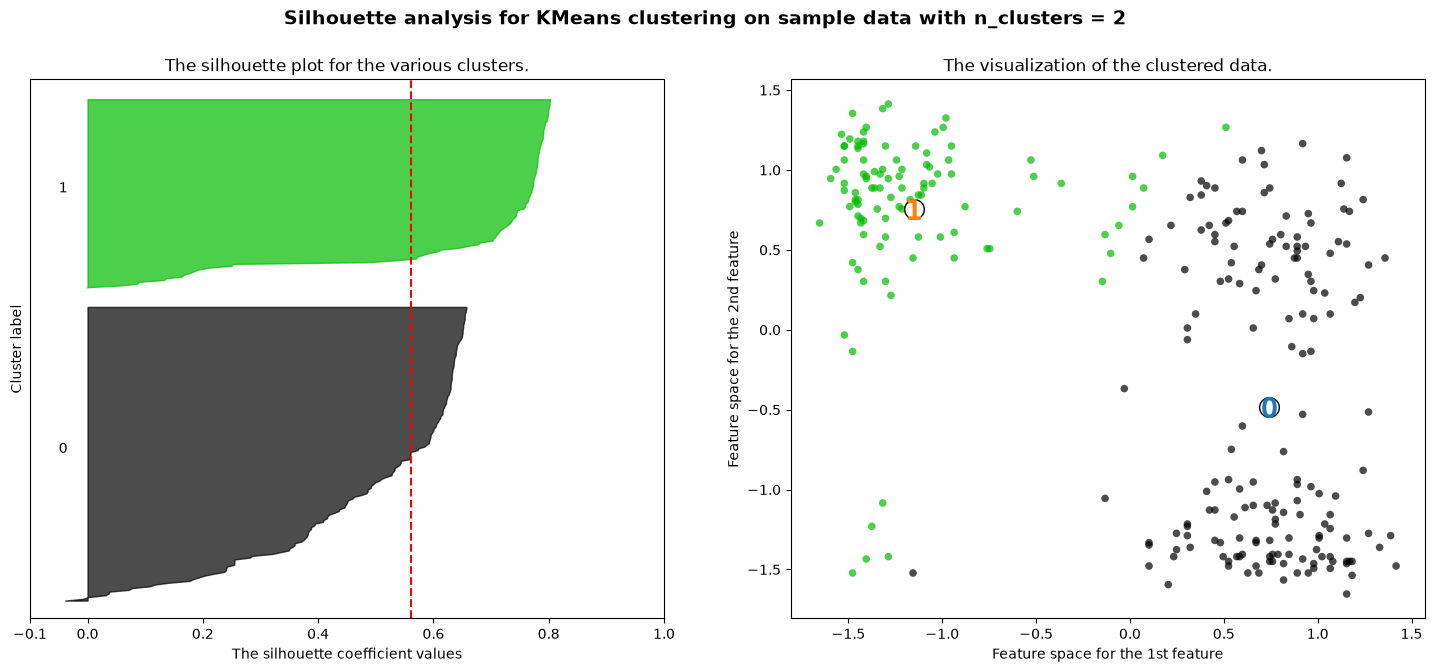

In [15]:
import matplotlib.cm as cm
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(18, 7)
# The 1st subplot is the silhouette plot
# The silhouette coefficient can range from -1, 1 but in this example all
# lie within [-0.1, 1]
ax1.set_xlim([-0.1, 1])
# The (n_clusters+1)*10 is for inserting blank space between silhouette
# plots of individual clusters, to demarcate them clearly.
ax1.set_ylim([0, len(data_faithful) + (ncluster + 1) * 10])

# Initialize the clusterer with n_clusters value and a random generator
# seed of 10 for reproducibility.
clusterer = KMeans(n_clusters=ncluster, random_state=10)
cluster_labels = clusterer.fit_predict(data_faithful)

# The silhouette_score gives the average value for all the samples.
# This gives a perspective into the density and separation of the formed
# clusters
silhouette_avg = silhouette_score(data_faithful, cluster_labels)
print(
    "For n_clusters =",
    ncluster,
    "The average silhouette_score is :",
    silhouette_avg,
)

# Compute the silhouette scores for each sample
sample_silhouette_values = silhouette_samples(data_faithful, cluster_labels)

y_lower = 10
for i in range(ncluster):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / ncluster)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("The silhouette plot for the various clusters.")
ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster label")

# The vertical line for average silhouette score of all the values
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

ax1.set_yticks([])  # Clear the yaxis labels / ticks
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# 2nd Plot showing the actual clusters formed
colors = cm.nipy_spectral(cluster_labels.astype(float) / ncluster)
ax2.scatter(
    data_faithful[:, 0], data_faithful[:, 1], marker="o", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
)

# Labeling the clusters
centers = clusterer.cluster_centers_
# Draw white circles at cluster centers
ax2.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="o",
    c="white",
    alpha=1,
    s=200,
    edgecolor="k",
)

for i, c in enumerate(centers):
    ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=200, edgecolor=None)

ax2.set_title("The visualization of the clustered data.")
ax2.set_xlabel("Feature space for the 1st feature")
ax2.set_ylabel("Feature space for the 2nd feature")

plt.suptitle(
    "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
    % ncluster,
    fontsize=14,
    fontweight="bold",
)

### Choice of the number of clusters: the Elbow Method

The elbow method is designed to find the optimal number of clusters. It consists in performing the clustering algorithm with an increasing number of clusters $k$, and measuring the average distance between data points and the cluster centroids. There are two typical metrics in the Elbow method:

* **Distortion**: It is calculated as the average of the squared distances from the cluster centers of the respective clusters. Typically, the Euclidean distance metric is used.
* **Inertia**: It is the sum of squared distances of samples to their closest cluster center.

For each value of $k$, we compute the mean of the square of the distance between the data points and the centroid of the cluster to which they belong. We then plot this value as a function of $k$. Hopefully, it decreases and then reaches a plateau. The optimal number of clusters is the value at the kink — the "elbow" of the curve.

We illustrate the method on the standardized Old Faithful data.

In [16]:
def compute_elbow(data, clusters, centers, k):
    """
    """
    E = 0
    for i in range(0, k):
        distance = compute_distance(data[clusters == i, :], centers[i, :].reshape(1, -1), 1)
        E = E + np.mean(np.square(distance))
    return E

Compute the value of E for k between 1 and 8 and plot it. Look for the value of $k$ where the curve bends.

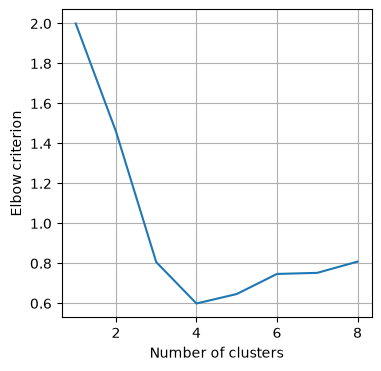

In [17]:
np.random.seed(3)
E = np.zeros(8)
for k in range(1, 9):
    (clusters, objective, centers) = my_kmeans(data_faithful, k)
    E[k - 1] = compute_elbow(data_faithful, clusters, centers, k)

plt.figure(figsize=(4, 4))
plt.plot(np.arange(1, 9), E)
plt.xlabel('Number of clusters')
plt.ylabel('Elbow criterion')
plt.grid(True)

The elbow method does not always work very well. For example, see what happens when the points get closer to each other. Because `data_faithful` is standardized and centered at zero, we shrink the data toward the origin.

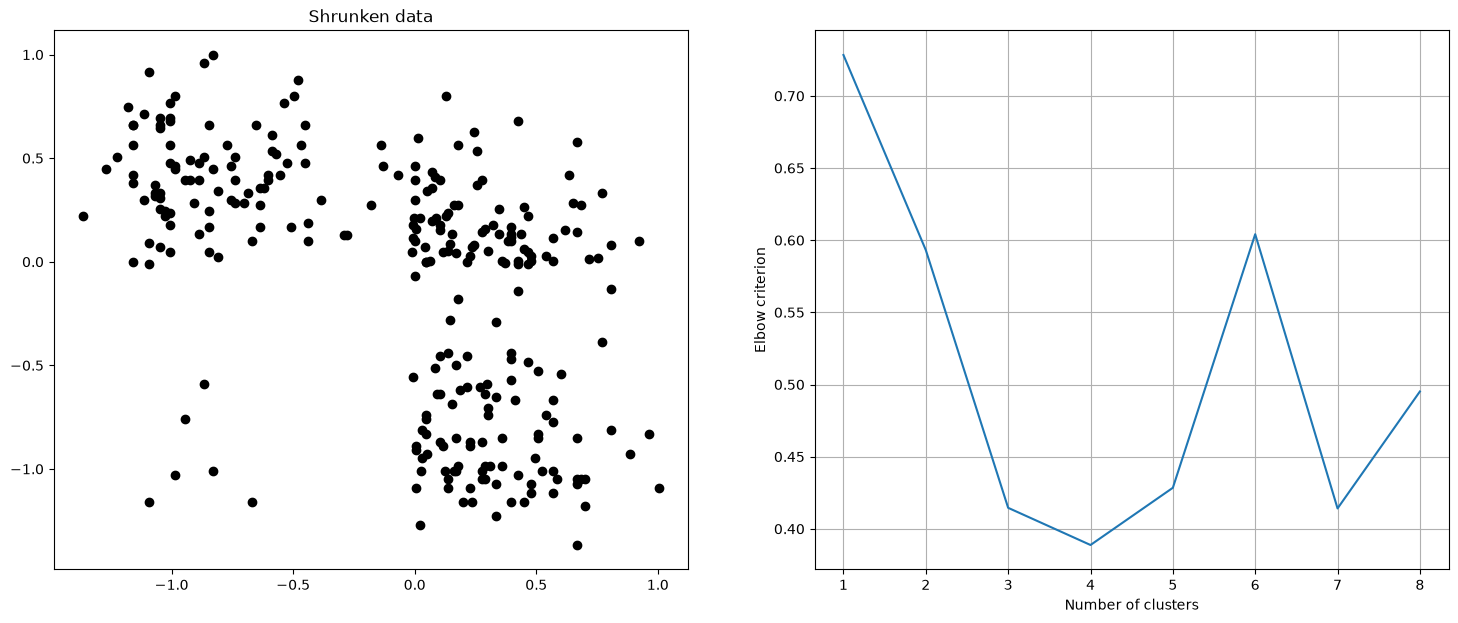

In [18]:
np.random.seed(3)
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(18, 7)
alpha = 0.5
origin = np.array([0.0, 0.0])
data_shrink = origin + alpha * np.sign(data_faithful - origin) * np.power(np.abs(data_faithful - origin), 2.0)
ax1.plot(data_shrink[:, 0], data_shrink[:, 1], 'ko')
ax1.set_title('Shrunken data')

E = np.zeros(8)
for k in range(1, 9):
    (clusters, objective, centers) = my_kmeans(data_shrink, k)
    E[k - 1] = compute_elbow(data_shrink, clusters, centers, k)
ax2.plot(np.arange(1, 9), E)
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Elbow criterion')
ax2.grid(True)

Let us see what happens when we decrease the number of data.

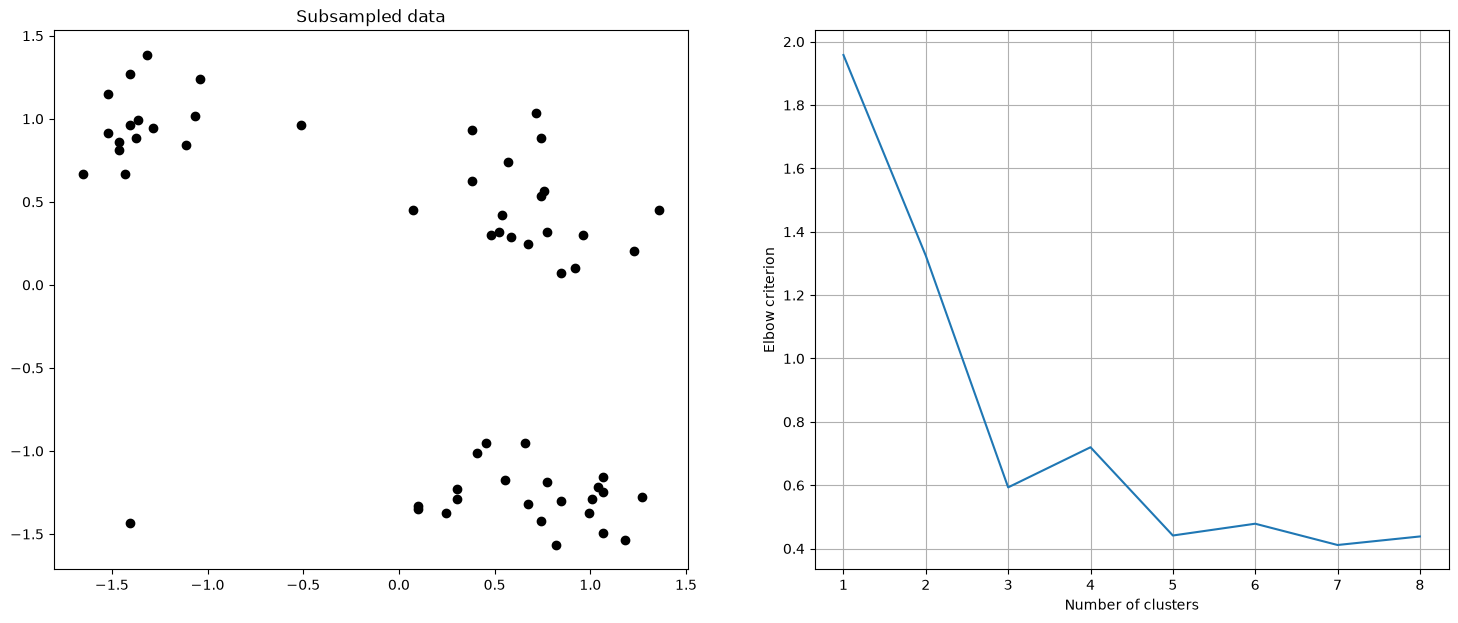

In [19]:
np.random.seed(4)
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(18, 7)
alpha = 0.2
indices = np.random.uniform(size=np.shape(data_faithful)[0])
subdata = data_faithful[indices < alpha, :]
ax1.plot(subdata[:, 0], subdata[:, 1], 'ko')
ax1.set_title('Subsampled data')
E = np.zeros(8)
for k in range(1, 9):
    (clusters, objective, centers) = my_kmeans(subdata, k)
    E[k - 1] = compute_elbow(subdata, clusters, centers, k)
ax2.plot(np.arange(1, 9), E)
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Elbow criterion')
ax2.grid(True)

Both stress tests show the limits of the elbow criterion: when the clusters get closer together, or when the data get sparse, the curve loses its clear kink and the choice of $k$ becomes ambiguous. Use the elbow method as a guide, not a rule, and cross-check with the silhouette score.

### Repeat K-means
The result is very sensitive to the location of the initial centroids. Repeat the clustering N times and choose the clustering with the best objective function.

In [20]:
def repeat_kmeans(data, k, N):
    """
    """
    # Initialization
    objective = np.zeros(N)
    clusters = np.zeros((N, np.shape(data)[0]))
    centers = np.zeros((N, k, np.shape(data)[1]))
    # Run K-means N times
    for i in range(0, N):
        result = my_kmeans(data, k)
        clusters[i, :] = result[0]
        objective[i] = result[1]
        centers[i, :, :] = result[2]
    # Choose the clustering with the best value of the objective function
    best = np.argmin(objective)
    return (clusters[best, :], objective[best], centers[best, :, :])

Repeat k-means 20 times with k = 2 and keep the best run.

Text(0.5, 1.0, 'Best of 20 k-means runs')

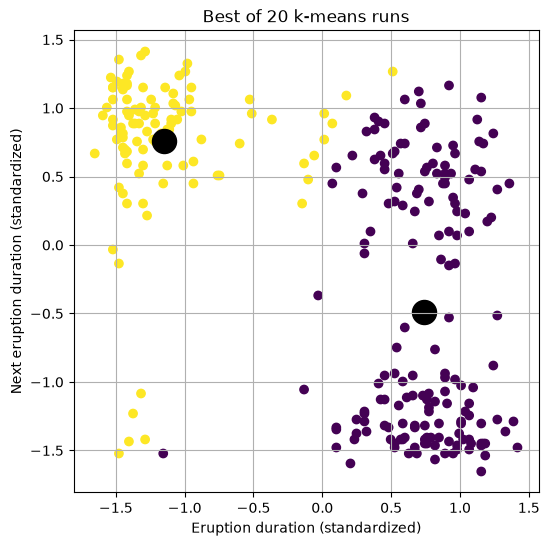

In [21]:
np.random.seed(5)
N = 20
k = 2
(clusters, objective, centers) = repeat_kmeans(data_faithful, k, N)

plt.figure(figsize=(6, 6))
plt.scatter(data_faithful[:, 0], data_faithful[:, 1], c=clusters)
plt.scatter(centers[:, 0], centers[:, 1], marker='o', s=300, c='black')
plt.xlabel('Eruption duration (standardized)')
plt.ylabel('Next eruption duration (standardized)')
plt.grid(True)
plt.title('Best of {:d} k-means runs'.format(N))

K-means can be a slow process to calculate and there are avenues to speed this up. One solution is to do [**mini-batch** K-means](https://scikit-learn.org/stable/modules/clustering.html#mini-batch-k-means), which takes a subset of data at each iteration to construct the centroids.

## 4. Hierarchical Clustering

In K-means, we use the euclidian distance and prescribe the number of clusters K.

In hierarchical clustering, we choose difference distance metrics, visualize the data structure, and then decide on the number of clusters. There are two approaches to building the hierarchy of clusters:

* **Agglomerative**: each point starts in each unique cluster. data is merged in pairs as on creates a hierarchy of clusters.
* **Divisive**: initially, all data is into 1 cluster. The data is recursively split into smaller and smaller clusters.

There are several types of *linkages*. sklearn has detailed [documentation](https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering), mostly for agglomerative: The different linkages methods are:

* **Ward** minimizes the sum of squared differences within all clusters. It is a variance-minimizing approach and in this sense is similar to the k-means objective function but tackled with an agglomerative hierarchical approach.
* **Maximum** or complete linkage minimizes the maximum distance between observations of pairs of clusters.
* **Average** linkage minimizes the average of the distances between all observations of pairs of clusters.
* **Single** linkage minimizes the distance between the closest observations of pairs of clusters.

We first import relevant packages.

In [22]:
from matplotlib import rcParams
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist

rcParams.update({'font.size': 18})
plt.rcParams['figure.figsize'] = [12, 12]

Here, we create a fake data set that has 2 clusters that intermingle in a few data points.

In [23]:
np.random.seed(42)

# Training and testing set sizes
n = 100 # Train

# Random ellipse 1 centered at (0,0)
x = np.random.randn(n)
y = 0.5*np.random.randn(n)

# Random ellipse 2 centered at (1,-2)
x2 = np.random.randn(n) + 1
y2 = 0.2*np.random.randn(n) - 2

# Rotate ellipse 2 by theta
theta = np.pi/4
A = np.zeros((2,2))
A[0,0] = np.cos(theta)
A[0,1] = -np.sin(theta)
A[1,0] = np.sin(theta)
A[1,1] = np.cos(theta)

x3 = A[0,0]*x2 + A[0,1]*y2
y3 = A[1,0]*x2 + A[1,1]*y2

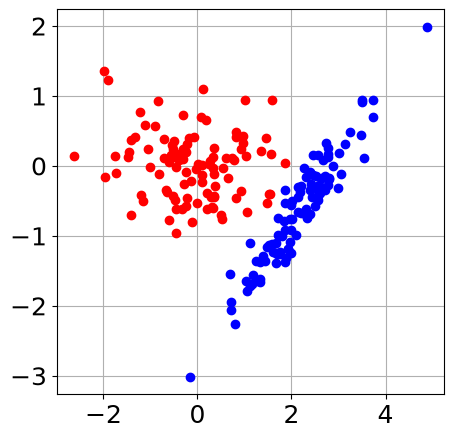

In [24]:
plt.figure(1,figsize=(5,5))
plt.plot(x[:],y[:],'ro')
plt.plot(x3[:],y3[:],'bo')
plt.grid(True)
plt.show()

Combine these two data sets as one.

In [25]:
X1 = np.column_stack((x3[:],y3[:]))
X2 = np.column_stack((x[:],y[:]))
X = np.concatenate((X1,X2))

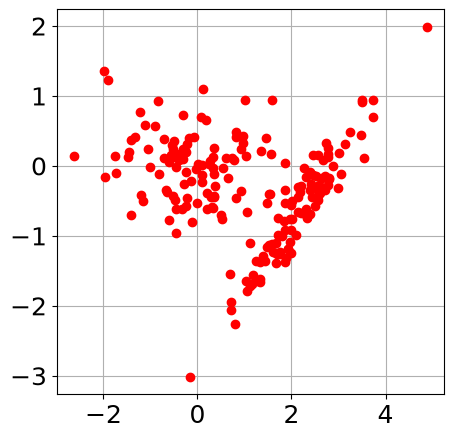

In [26]:
plt.figure(1,figsize=(5,5))
plt.plot(X[:,0],X[:,1],'ro')
plt.grid(True)
plt.show()

First we explore the dendrograms.

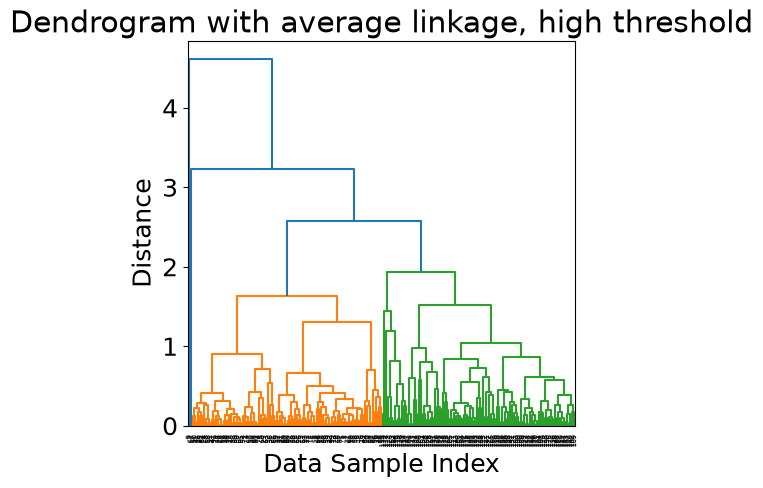

In [27]:
## Dendrograms
Y = pdist(X,metric='euclidean')
Z = hierarchy.linkage(Y,method='average')
thresh = 0.5*np.max(Z[:,2])

plt.figure(1,figsize=(5,5))
dn = hierarchy.dendrogram(Z,p=100,color_threshold=thresh)
plt.xlabel('Data Sample Index')
plt.ylabel('Distance')
plt.title('Dendrogram with average linkage, high threshold')
plt.show()

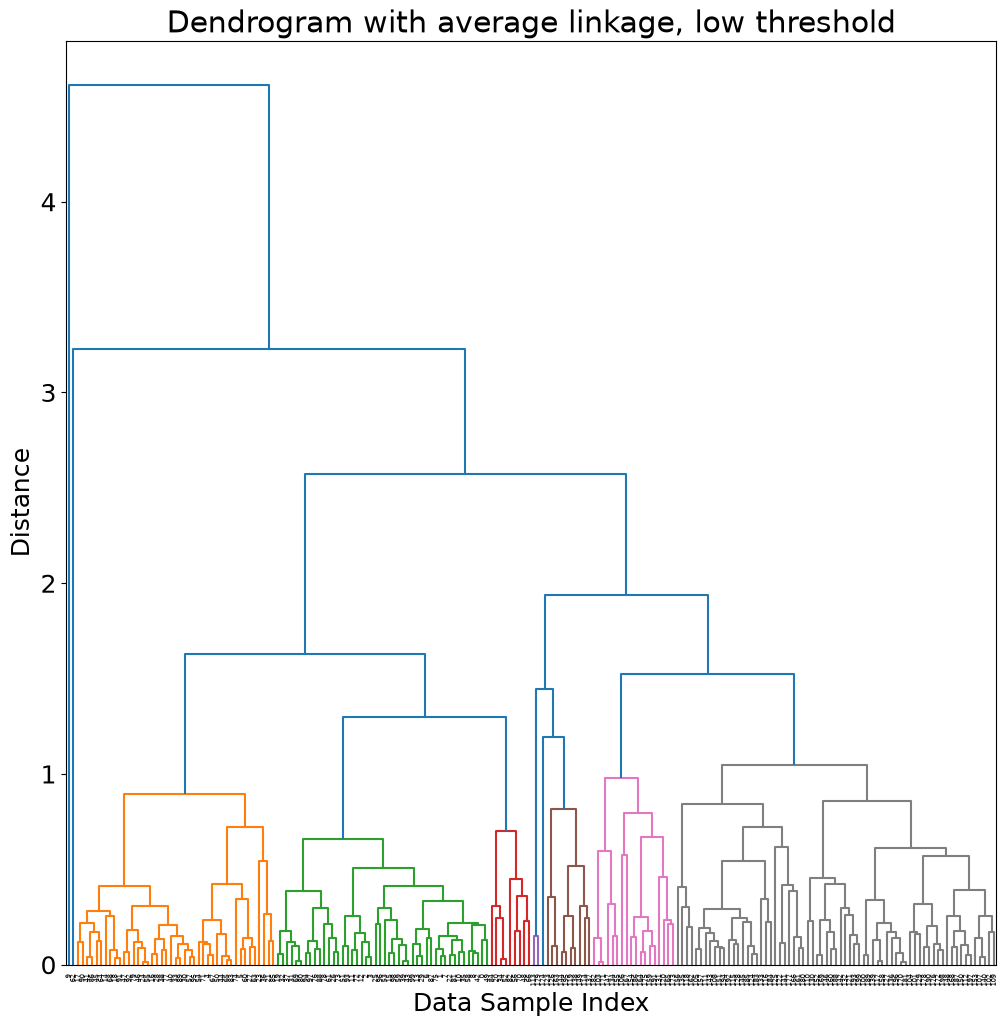

In [28]:
thresh = 0.25*np.max(Z[:,2])
plt.figure()
dn = hierarchy.dendrogram(Z,p=100,color_threshold=thresh)
plt.xlabel('Data Sample Index')
plt.ylabel('Distance')
plt.title('Dendrogram with average linkage, low threshold')
plt.show()

Now that we have explored the structure of the data and built some intuition on how many clusters and the distribution of the data samples in the cluster.

Next, we choose a distance threshold and assign each data point to a cluster ID.

In Sci-kit learn, the entire algorithm is incorporated in the function ```AgglomerativeClustering``` [sklearn doc here](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html). The function still needs either a threshold distance or a number of clusters to perform the clustering and assign a cluster ID to each data sample.

In [29]:
from sklearn.cluster import AgglomerativeClustering
# Let's first find a reasonable distance threshold by precalculating the linkage matrix
Z = hierarchy.linkage(X, "average")
thresh = 0.85*np.max(Z[:,2])    # choose a threshold distance
print(thresh)
# design model
model = AgglomerativeClustering(distance_threshold=thresh,linkage="average", n_clusters=None)
# fit model and predict clusters on the data samples
clusterID = model.fit_predict(X)

3.9214276215175303


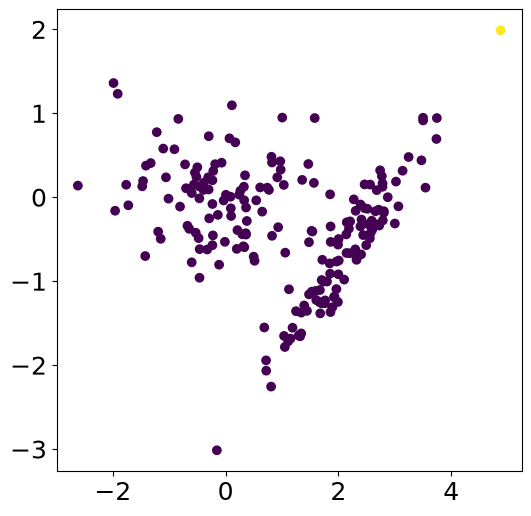

In [30]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0],X[:,1],c=clusterID)

## 5. PCA before clustering

Let us generate synthetic data.

(-6.0, 3.0)

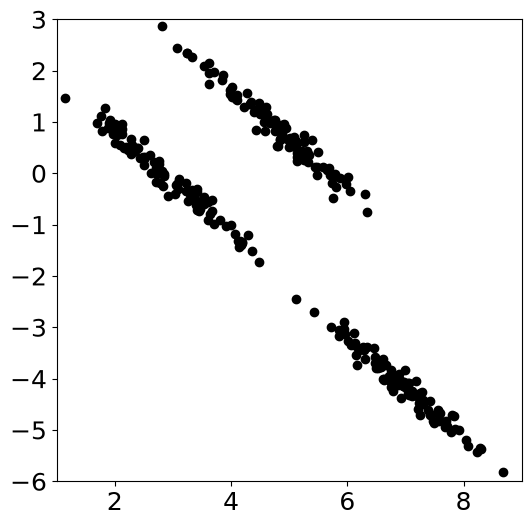

In [31]:
np.random.seed(0)
centers = np.array([[2, 2], [2, 8], [4, 3]])
radius = [0.1, 1]
synthetics = np.empty([0, 2])
for i in range(0, 3):
    X = centers[i, 0] + radius[0] * np.random.randn(100)
    Y = centers[i, 1] + radius[1] * np.random.randn(100)
    U = (X + Y) * np.sqrt(2) / 2
    V = (X - Y) * np.sqrt(2) / 2
    synthetics = np.concatenate([synthetics, np.vstack((U, V)).T])
plt.figure(figsize=(6,6))
plt.plot(synthetics[:,0], synthetics[:,1], 'ko')
plt.xlim(1, 9)
plt.ylim(-6, 3)

Let us now do k-means clustering with 3 clusters.

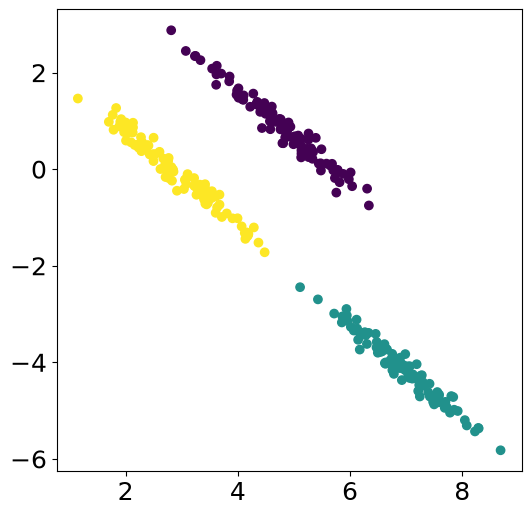

In [32]:
np.random.seed(0)
(clusters, objective, centers) = my_kmeans(synthetics, 3)
plt.figure(figsize=(6,6))
plt.scatter(synthetics[:,0], synthetics[:,1], c=clusters)

What happens if we apply PCA + normalization before the clustering?

In [33]:
pca = PCA(n_components=2)
synthetics_pca = pca.fit_transform(synthetics)

In [34]:
scaler = preprocessing.StandardScaler().fit(synthetics_pca)
synthetics_scaled = scaler.transform(synthetics_pca)

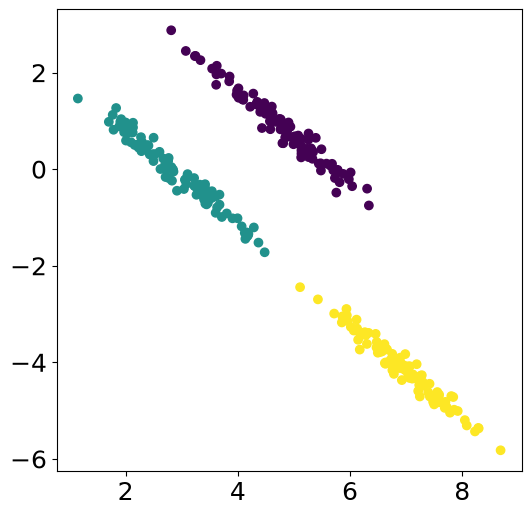

In [35]:
np.random.seed(0)
(clusters, objective, centers) = my_kmeans(synthetics_scaled, 3)
plt.figure(figsize=(6,6))
plt.scatter(synthetics[:,0], synthetics[:,1], c=clusters)

## Exercise: clustering volcanic and tectonic seismic sources

Volcanoes like Mt Hood, an ice-capped volcano in the Cascades, produce a mix of seismic sources: volcanic and tectonic earthquakes, surface events such as rockfalls and avalanches, and background noise. Analysts label these events by hand. Can clustering find the source types from waveform features alone?

We use a curated dataset of Pacific Northwest seismic events — earthquake, explosion, surface event, and noise, 1000 of each — described by physical waveform features (spectral shape, envelope statistics, kurtosis, band energies). The dataset is archived on Zenodo: [DOI 10.5281/zenodo.14025693](https://doi.org/10.5281/zenodo.14025693). It returns in notebook 3.5 for supervised classification.

**Step 1: load the data.** The loader below downloads and caches the four class files, concatenates them, and drops the one feature column with missing values.

In [36]:
import pooch

SEISMIC_FILES = {
    "1000_earthquakes_physical_features.csv": "md5:28129c8dd1b3e14f655d489577b841b5",
    "1000_explosion_physical_features.csv": "md5:af1342d32e163e961e043364136359b0",
    "1000_noise_physical_features.csv": "md5:16cdb992fed6cf6273d5624f5df905da",
    "1000_surface_physical_features.csv": "md5:9a2c2643030cf058704d68e130654e9d",
}

frames = []
for fname, checksum in SEISMIC_FILES.items():
    path = pooch.retrieve(
        url=f"https://zenodo.org/api/records/14025693/files/{fname}/content",
        known_hash=checksum,
        fname=fname,
        path=pooch.os_cache("mlgeo"),
    )
    frames.append(pd.read_csv(path, index_col=0))
seismic = pd.concat(frames, ignore_index=True)
seismic = seismic.dropna(axis=1)  # drops the one feature column with missing values

In [37]:
X_seis = seismic.drop(columns=["source", "serial_no"])
y_seis = seismic["source"]
print(X_seis.shape)
y_seis.value_counts()

(4000, 61)


source
earthquake       1000
explosion        1000
noise            1000
surface event    1000
Name: count, dtype: int64

**Step 2: standardize the 61 features.** The features span orders of magnitude, so scaling is mandatory before any distance-based method.

In [38]:
scaler = preprocessing.StandardScaler()
X_seis_scaled = scaler.fit_transform(X_seis)

**Step 3: PCA.** Plot the cumulative explained variance and keep enough principal components to explain about 80% of the variance.

15 components explain 80% of the variance


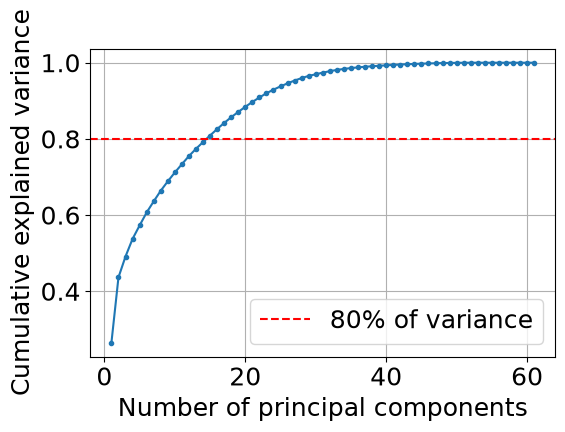

In [39]:
pca = PCA().fit(X_seis_scaled)
cumvar = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(cumvar) + 1), cumvar, marker='.')
plt.axhline(0.80, color='red', linestyle='--', label='80% of variance')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance')
plt.legend()
plt.grid(True)

n_pcs = int(np.searchsorted(cumvar, 0.80) + 1)
print(f"{n_pcs} components explain 80% of the variance")
X_seis_pca = pca.transform(X_seis_scaled)[:, :n_pcs]

**Step 4: k-means with 4 clusters** on the principal components. We know there are four source types, so we set k = 4.

In [40]:
kmeans_seis = KMeans(n_clusters=4, random_state=42).fit(X_seis_pca)
cluster_labels = kmeans_seis.labels_

**Step 5: compare the clusters to the true labels.** This dataset has ground-truth labels, so we can score the clustering with three metrics:

* **Homogeneity** is 1 when each cluster contains members of a single class only.
* **Completeness** is 1 when all members of a class land in the same cluster.
* **V-measure** is the harmonic mean of the two. All three range from 0 (random assignment) to 1 (perfect match).

In [41]:
h, c, v = metrics.homogeneity_completeness_v_measure(y_seis, cluster_labels)
print(f"Homogeneity:  {h:.3f}")
print(f"Completeness: {c:.3f}")
print(f"V-measure:    {v:.3f}")

Homogeneity:  0.363
Completeness: 0.393
V-measure:    0.377


**Step 6: cross-tabulate clusters against source types.**

In [42]:
ct = pd.crosstab(cluster_labels, y_seis, rownames=['cluster'], colnames=['source'])
ct

source,earthquake,explosion,noise,surface event
cluster,,,,
0,141,732,14,794
1,71,52,698,125
2,764,117,41,48
3,24,99,247,33


Text(0.5, 1.0, 'K-means clusters vs. true source types')

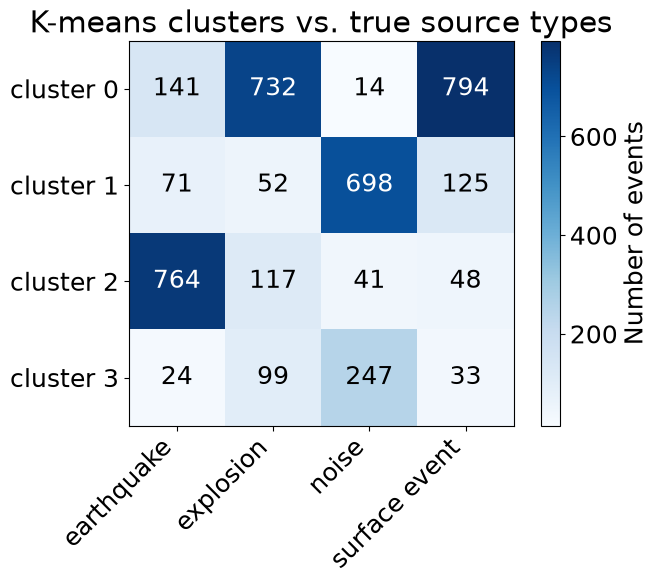

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(ct.values, cmap='Blues')
ax.set_xticks(range(len(ct.columns)))
ax.set_xticklabels(ct.columns, rotation=45, ha='right')
ax.set_yticks(range(len(ct.index)))
ax.set_yticklabels([f'cluster {i}' for i in ct.index])
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, ct.values[i, j], ha='center', va='center',
                color='white' if ct.values[i, j] > ct.values.max()/2 else 'black')
fig.colorbar(im, ax=ax, label='Number of events')
ax.set_title('K-means clusters vs. true source types')

Without ever seeing a label, k-means recovers a good part of the structure: one cluster is dominated by earthquakes and another by noise. Look at your crosstab for the pair of sources that mixes the most — here, explosions and surface events largely share a cluster. That is physically plausible: both are shallow, near-surface sources (quarry blasts, rockfalls, avalanches), so their waveforms carry little of the deep high-frequency energy that separates earthquakes, and their envelope and spectral features overlap. The supervised classifiers in notebook 3.5 do much better on the same features, which is the point of labels.

```{admonition} Your turn
:class: tip
* Vary k from 2 to 8 and track the silhouette score and the inertia (elbow method). Does k = 4 stand out?
* Try clustering on the scaled features without PCA. Does the V-measure change?
* Try `AgglomerativeClustering` with 4 clusters and compare its V-measure to k-means.
```